# Importar librerías

In [31]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


# Librerías de simulación y análisis

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
    calcular_apex_3d_gaia,
)
from src.sky_apex_plotter import plot_cluster_motion_geometry

In [4]:
# # antapex solar
# l = 312.20
# b = -23.70

# coord_gal = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic')
# coord_icrs = coord_gal.icrs

# coord_icrs, coord_icrs.ra.deg, coord_icrs.dec.deg

In [5]:
# # apex solar
# l = 47.8
# b = 23.7

# coord_gal = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic')
# coord_icrs = coord_gal.icrs

# coord_icrs, coord_icrs.ra.deg, coord_icrs.dec.deg

In [6]:
from astropy.coordinates import SkyCoord
from astropy import units as u

# # Punto 1
# l1 = 312.20
# b1 = -23.70

# # Punto 2
# l2 = 47.8
# b2 = 23.7

# coord1 = SkyCoord(l=l1*u.deg, b=b1*u.deg, frame="galactic")
# coord2 = SkyCoord(l=l2*u.deg, b=b2*u.deg, frame="galactic")

# sep = coord1.separation(coord2)

# print(sep)
# print(sep.deg)

# Cargue de datos

In [7]:
cluster_real = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")
cluster_real = cluster_real[cluster_real["ConteoAgrupaciones"]>0].copy()

In [8]:
cluster_real = correct_gaia_proper_motions(
    cluster_real,
    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",
    pmra_col="pmra",
    pmdec_col="pmdec",
    correct_solar_reflex=True
)
cluster_real["peso"] = cluster_real["probabilidad"]**10

In [9]:
import astropy.units as u
from astropy.coordinates import SkyCoord

coord_gal = SkyCoord(l=177.565674*u.deg, b=-25.7529*u.deg, frame='galactic')
coord_icrs = coord_gal.icrs

# Configuración de simulaciones

## Configuración de sintéticas

In [10]:
# ============================================================
# Modelos de error reutilizables
# ============================================================

PMRA_LOG10_TRIANGULAR_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,
)

PMDEC_LOG10_TRIANGULAR_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,
)

GAIA_LIKE_PM_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,

    # Relación empírica:
    # pmdec_error ≈ 0.7 * pmra_error
    pm_error_slope=1,

    # Correlación entre perturbaciones de pmra y pmdec.
    pmra_pmdec_corr=0.2,

    # Dispersión alrededor de la pendiente 0.7.
    pm_error_slope_logscatter=0.08,
)


# ============================================================
# Caso 1: cúmulo ideal con ápex Hyades
# ============================================================

config_hyades = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,
)


# ============================================================
# Caso 2: cúmulo ideal con ápex solar
# ============================================================

config_hyades_solar = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=227.79628626384542,
    apex_dec_deg=-23.69031810716205,

    speed_kms=25.0,
    seed=42,
)


# ============================================================
# Caso 3: solo error en paralaje
# ============================================================

config_hyades_error_parallax = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Solo error observacional en paralaje
    parallax_error_mas=0.03,
)


# ============================================================
# Caso 4: solo error en pmra
# pmra_error viene de:
# log10(pmra_error) ~ Triangular(-3, -1.7, 0)
# ============================================================

config_hyades_error_pmra = ClusterSimulationConfig(
    n_members=455,
    center_ra_deg=67.0,
    center_dec_deg=17.0,
    distance_pc=85.0,
    radius_pc=5.0,
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,
    speed_kms=25.0,
    seed=42,
    **PMRA_LOG10_TRIANGULAR_ERROR,
)


# ============================================================
# Caso 5: solo error en pmdec
# Este lo mantengo constante porque el modelo triangular fue
# definido explícitamente para pmra_error.
# ============================================================

config_hyades_error_pmdec = ClusterSimulationConfig(
    n_members=455,
    center_ra_deg=67.0,
    center_dec_deg=17.0,
    distance_pc=85.0,
    radius_pc=5.0,
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,
    speed_kms=25.0,
    seed=42,
    **PMDEC_LOG10_TRIANGULAR_ERROR,
)


# ============================================================
# Caso 6: errores en pmra y pmdec Gaia-like
#
# pmra_error:
# log10(pmra_error) ~ Triangular(-3, -1.7, 0)
#
# pmdec_error:
# pmdec_error ≈ 0.7 * pmra_error
#
# perturbaciones:
# corr(dpmra, dpmdec) = 0.2
# ============================================================

config_hyades_error_pm = ClusterSimulationConfig(
    n_members=455,
    center_ra_deg=67.0,
    center_dec_deg=17.0,
    distance_pc=85.0,
    radius_pc=5.0,
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,
    speed_kms=25.0,
    seed=42,
    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,
)


# ============================================================
# Caso 7: paralaje + movimientos propios Gaia-like
# ============================================================

config_hyades_error_all = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Error en paralaje
    parallax_error_mas=0.04,

    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,
)

# ============================================================
# Caso 8: dispersión física/intrínseca en velocidad
#
# Importante:
# speed_sigma_kms no es un error observacional Gaia.
# Es una dispersión real de velocidades dentro del cúmulo.
# Para un cúmulo abierto realista, 5 km/s es bastante alto.
# Puedes usarlo como prueba extrema, pero para algo más físico
# usaría valores como 0.3, 0.5 o 1.0 km/s.
# ============================================================

config_hyades_error_dispersion = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Dispersión física, no error observacional
    speed_sigma_kms=5.0,
)


# ============================================================
# Caso 9: paralaje + movimientos propios Gaia-like
#         + dispersión física/intrínseca en velocidad
# ============================================================

config_hyades_error_alld = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Error en paralaje
    parallax_error_mas=0.03,

    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,

    # Dispersión física, no error observacional
    speed_sigma_kms=5.0,
)

## generación de simulaciones sintéticas

In [11]:
# ejecución de simulación del cúmulo sintético de las hyades
simulator_hyades = OpenClusterSimulator(config_hyades)
simulator_hyades_solar = OpenClusterSimulator(config_hyades_solar)
simulator_hyades_error_parallax = OpenClusterSimulator(config_hyades_error_parallax)
simulator_hyades_error_pmra = OpenClusterSimulator(config_hyades_error_pmra)
simulator_hyades_error_pmdec = OpenClusterSimulator(config_hyades_error_pmdec)
simulator_hyades_error_pm = OpenClusterSimulator(config_hyades_error_pm)
simulator_hyades_error_all = OpenClusterSimulator(config_hyades_error_all)
simulator_hyades_error_dispersion = OpenClusterSimulator(config_hyades_error_dispersion)
simulator_hyades_error_alld = OpenClusterSimulator(config_hyades_error_alld)

hyades_sintetico = simulator_hyades.simulate()
hyades_sintetico["cluster_id"] ="0_8"
hyades_sintetico["grupo"] = "1"

hyades_sintetico_solar = simulator_hyades_solar.simulate()
hyades_sintetico_solar["cluster_id"] ="0_8"
hyades_sintetico_solar["grupo"] = "1"

hyades_sintetico_error_parallax = simulator_hyades_error_parallax.simulate()
hyades_sintetico_error_parallax["cluster_id"] ="0_8"
hyades_sintetico_error_parallax["grupo"] = "1"

hyades_sintetico_error_pmra = simulator_hyades_error_pmra.simulate()
hyades_sintetico_error_pmra["cluster_id"] ="0_8"
hyades_sintetico_error_pmra["grupo"] = "1"

hyades_sintetico_error_pmdec = simulator_hyades_error_pmdec.simulate()
hyades_sintetico_error_pmdec["cluster_id"] ="0_8"
hyades_sintetico_error_pmdec["grupo"] = "1"

hyades_sintetico_error_pm = simulator_hyades_error_pm.simulate()
hyades_sintetico_error_pm["cluster_id"] ="0_8"
hyades_sintetico_error_pm["grupo"] = "1"

hyades_sintetico_error_all = simulator_hyades_error_all.simulate()
hyades_sintetico_error_all["cluster_id"] ="0_8"
hyades_sintetico_error_all["grupo"] = "1"

hyades_sintetico_error_dispersion = simulator_hyades_error_dispersion.simulate()
hyades_sintetico_error_dispersion["cluster_id"] ="0_8"
hyades_sintetico_error_dispersion["grupo"] = "1"

hyades_sintetico_error_alld = simulator_hyades_error_alld.simulate()
hyades_sintetico_error_alld["cluster_id"] ="0_8"
hyades_sintetico_error_alld["grupo"] = "1"

## Generación de simulaciones semi-sintéticas

In [12]:
apex_hyades_ra = 97.89
apex_hyades_dec = 6.61
apex_solar_ra = 227.79628626384542
apex_solar_dec = -23.69031810716205

# Simulacion con valores reportados de velocidad
simulado_uvw = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_solar_ra,
    apex_dec_deg=apex_solar_dec,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)


# Simulacion con el valor de apex del cumulo
simulado_apex = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_hyades_ra,
    apex_dec_deg=apex_hyades_dec,
    speed_kms=np.sqrt(41.92**2 + 19.35**2 + 1.11**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)


simulado_uvw_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_solar_ra,
    apex_dec_deg=apex_solar_dec,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)


# Simulacion con errores Gaia-like en movimientos propios
simulado_apex_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_solar_ra,
    apex_dec_deg=apex_solar_dec,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    # Aquí sí activas errores observacionales en movimientos propios
    apply_pmra_error=True,
    apply_pmdec_error=True,
    apply_parallax_error=False,

    # Error en pmra:
    # log10(pmra_error) ~ Triangular(-3, -1.7, 0)
    pmra_log_error_range=(-3.0, 0.0),
    pmra_log_error_center=-1.7,

    # Error en pmdec:
    # pmdec_error ≈ 0.7 * pmra_error
    pmdec_error_model="scaled_pmra",
    pm_error_slope=0.7,

    # Correlación entre las perturbaciones aleatorias
    # de pmra y pmdec
    pmra_pmdec_corr=0.2,

    # Dispersión alrededor de la pendiente 0.7.
    # Puedes poner 0.0 si quieres una línea exacta.
    pm_error_slope_logscatter=0.08,

    seed=42,
)

In [13]:
simulado_uvw[["apex_ra_deg","apex_dec_deg"]].describe()

,apex_ra_deg,apex_dec_deg
count,4.000000e+02,4.000000e+02
mean,2.277963e+02,-2.369032e+01
std,1.735896e-12,1.209435e-13
min,2.277963e+02,-2.369032e+01
25%,2.277963e+02,-2.369032e+01
50%,2.277963e+02,-2.369032e+01
75%,2.277963e+02,-2.369032e+01
max,2.277963e+02,-2.369032e+01


## generación de análisis sintéticos

In [14]:
# ejecucion de cálculo de ápex para cúmulo sintético
result_hyades_sintetico = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_solar = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_parallax = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_parallax,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmra = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmra,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmdec = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmdec,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)

result_hyades_sintetico_error_pm = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pm,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_all = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_all,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_dispersion = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_dispersion,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)

# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_alld = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_alld,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)

## Generación de resultados semi-sintéticos

In [15]:
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad = run_cluster_analysis_from_dataframe(
    df = simulado_uvw,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex = run_cluster_analysis_from_dataframe(
    df = simulado_apex,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad_solar = run_cluster_analysis_from_dataframe(
    df = simulado_uvw_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
    theta_clip_nsigma = 4,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex_solar = run_cluster_analysis_from_dataframe(
    df = simulado_apex_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
    theta_clip_nsigma = 4,
)
# ejecucion sobre caso clásico hyades
result_hyades_classic = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_col = "peso",
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecucion sobre caso clásico hyades
result_hyades_classic_corrected = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra_corr",
    pmdec_col = "pmdec_corr",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_col = "peso",
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
    theta_clip_nsigma = 4,
)
# ejecución sobre caso corregido hyades solar
result_hyades_classic_solar = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "d_pmra_corr",
    pmdec_col = "d_pmdec_corr",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    # weight_fill_value =  1,
    weight_col = "peso",
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
    theta_clip_nsigma = 4,
)

# Análisis de resultados

## Agrupación de resultados

In [16]:
all_results = {
    "Hy_s": result_hyades_sintetico["summary"],
    "Hy_s err plx": result_hyades_sintetico_error_parallax["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err pmdec": result_hyades_sintetico_error_pmdec["summary"],
    "Hy_s err pm": result_hyades_sintetico_error_pm["summary"],
    "Hy_s err all": result_hyades_sintetico_error_all["summary"],
    "Hy_s err dispersion": result_hyades_sintetico_error_dispersion["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err alld": result_hyades_sintetico_error_alld["summary"],
    "Hy_ss vel": result_hyades_semisintetico_velocidad["summary"],
    "Hy_ss apex": result_hyades_semisintetico_apex["summary"], 
    "Hy_s solar": result_hyades_sintetico_solar["summary"],
    "Hy_ss vel solar": result_hyades_semisintetico_velocidad_solar["summary"],
    "Hy_ss apex solar": result_hyades_semisintetico_apex_solar["summary"],
    "Hy_ss classic": result_hyades_classic["summary"],
    "Hy_ss classic corrected": result_hyades_classic_corrected["summary"],
    "Hy_ss classic solar": result_hyades_classic_solar["summary"],
}

In [17]:
df_results = pd.DataFrame(
    [
        {
            "type": result_name,
            **result_dict,
        }
        for result_name, result_dict in all_results.items()
    ]
)

df_results[["type","n_stars","true_apex_ra_deg","true_apex_dec_deg","apex_initial_ra_deg","apex_initial_dec_deg",'theta_pole_initial_rms_deg', 'theta_pole_axis_initial_median_deg',
       'theta_pole_axis_initial_rms_deg']]

,type,n_stars,true_apex_ra_deg,true_apex_dec_deg,apex_initial_ra_deg,apex_initial_dec_deg,theta_pole_initial_rms_deg,theta_pole_axis_initial_median_deg,theta_pole_axis_initial_rms_deg
0,Hy_s,455,97.890000,6.610000,97.890002,6.620000,3.074419e-07,0.000000e+00,3.074419e-07
1,Hy_s err plx,455,97.890000,6.610000,97.890002,6.620000,3.074419e-07,0.000000e+00,3.074419e-07
2,Hy_s err pmra,455,97.890000,6.610000,97.846253,6.634782,4.266799e-02,9.352210e-03,4.266799e-02
3,Hy_s err pmdec,455,97.890000,6.610000,97.846253,6.634782,4.266799e-02,9.352210e-03,4.266799e-02
4,Hy_s err pm,455,97.890000,6.610000,97.531694,6.755520,2.895098e-01,4.702086e-02,2.895098e-01
5,Hy_s err all,455,97.890000,6.610000,97.591815,6.741338,2.386029e-01,4.628872e-02,2.386029e-01
6,Hy_s err dispersion,455,97.890000,6.610000,97.890002,6.620000,3.921685e-07,0.000000e+00,3.921685e-07
7,Hy_s err alld,455,97.890000,6.610000,97.566349,6.749836,2.651120e-01,5.122148e-02,2.651120e-01
8,Hy_ss vel,400,97.890000,6.610000,227.796286,-23.690318,3.361310e-07,0.000000e+00,3.361310e-07
9,Hy_ss apex,400,97.890000,6.610000,97.890005,6.610001,1.337049e-06,8.537736e-07,1.337049e-06


In [18]:
result_hyades_sintetico_error_alld = result_hyades_classic.copy()

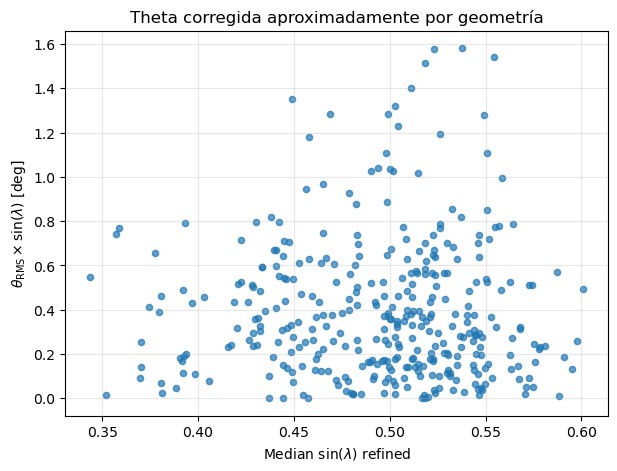

In [19]:
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_sin_lambda"] = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"]*result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_axis_refined_deg"]
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_cos_lambda"] = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["cos_lambda_refined"]*result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_axis_refined_deg"]
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["arc_sin_sin_theta_times_sin_lambda"] = np.arcsin(np.sin(result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_refined_deg"]*180/np.pi) * result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"])
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_theta_times_sin_lambda"] = np.sin(result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_refined_deg"]*180/np.pi) * result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"]
x = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"]
y = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_sin_lambda"]

mask = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(7, 5))
plt.scatter(x[mask], y[mask], s=20, alpha=0.7)

plt.xlabel(r"Median $\sin(\lambda)$ refined")
plt.ylabel(r"$\theta_{\rm RMS} \times \sin(\lambda)$ [deg]")
plt.title("Theta corregida aproximadamente por geometría")
plt.grid(alpha=0.3)
plt.show()

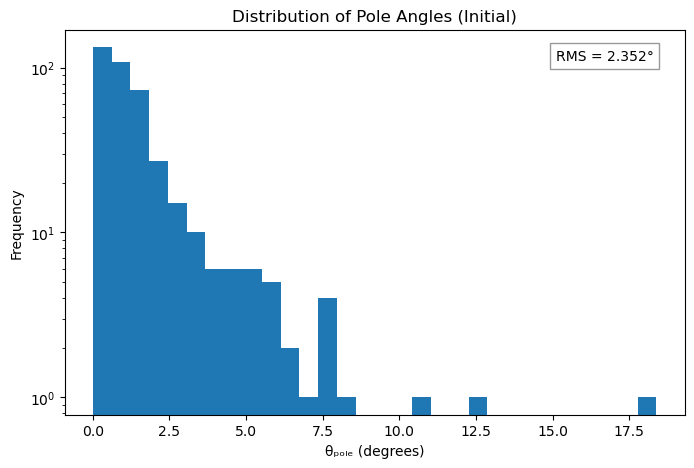

In [20]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["theta_pole_initial_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Pole Angles (Initial)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)
plt.yscale("log")
plt.show()

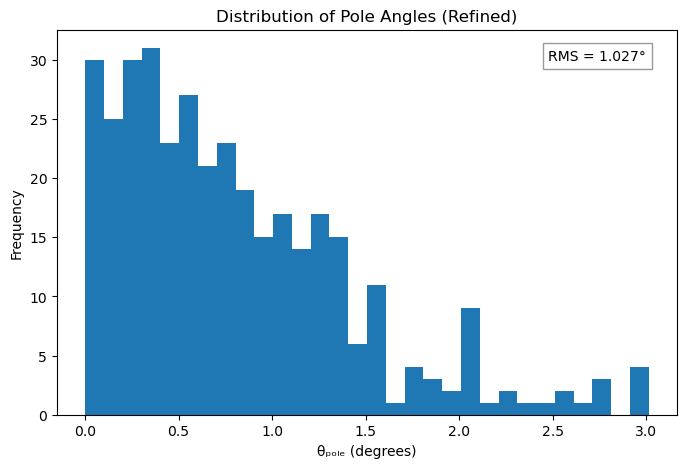

In [21]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_refined_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Pole Angles (Refined)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\;'
<>:15: SyntaxWarning: invalid escape sequence '\;'
C:\Users\nicob\AppData\Local\Temp\ipykernel_24480\33341055.py:15: SyntaxWarning: invalid escape sequence '\;'
  plt.xlabel("θₚₒₗₑ $sin\;\lambda$ (degrees)")


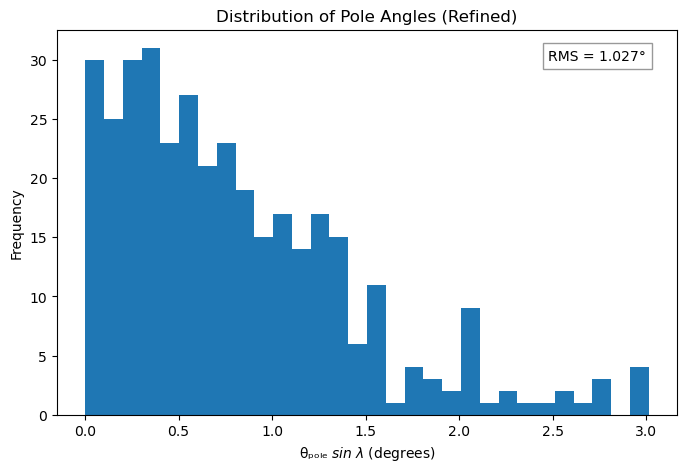

In [22]:
# Variable a graficar
# theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_sin_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ $sin\;\lambda$ (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Pole Angles (Refined)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\;'
<>:15: SyntaxWarning: invalid escape sequence '\;'
C:\Users\nicob\AppData\Local\Temp\ipykernel_24480\3954969377.py:15: SyntaxWarning: invalid escape sequence '\;'
  plt.xlabel("θₚₒₗₑ $cos\;\lambda$ (degrees)")


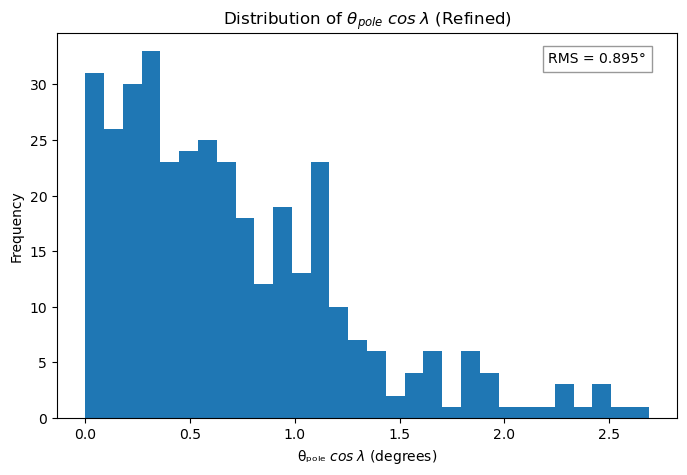

In [23]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_cos_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ $cos\;\lambda$ (degrees)")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\theta_{pole}\;cos\;\lambda$ (Refined)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

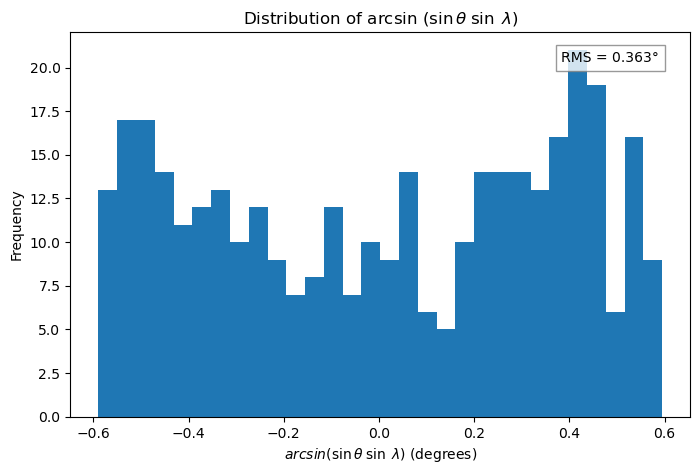

In [24]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["arc_sin_sin_theta_times_sin_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$ arcsin (\sin\theta\; \sin\;\lambda)$ (degrees)")
plt.ylabel("Frequency")
plt.title(r"Distribution of arcsin $(\sin\theta\; \sin\;\lambda)$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

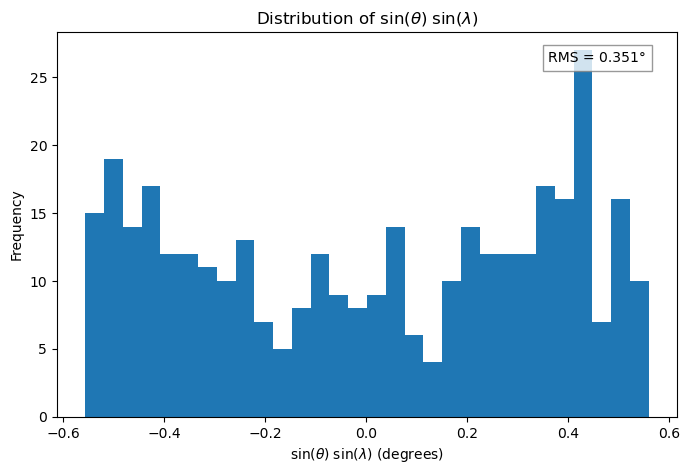

In [25]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_theta_times_sin_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$\sin(\theta)\; \sin(\lambda)$ (degrees)")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\sin(\theta)\; \sin(\lambda)$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

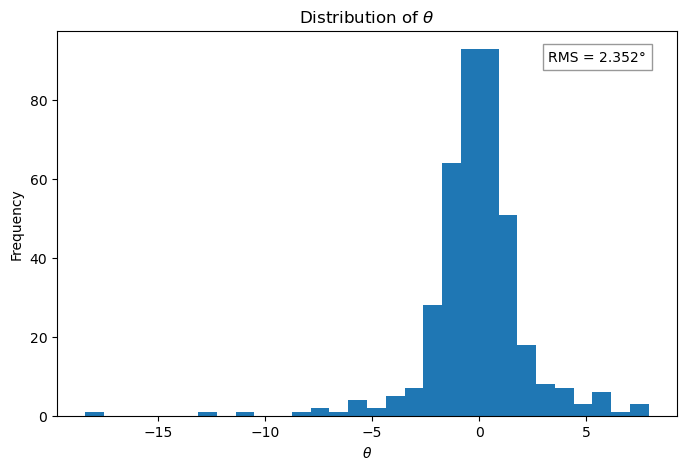

In [26]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["pole_apex_error_direction_signed_initial_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"${\theta}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of ${\theta}$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

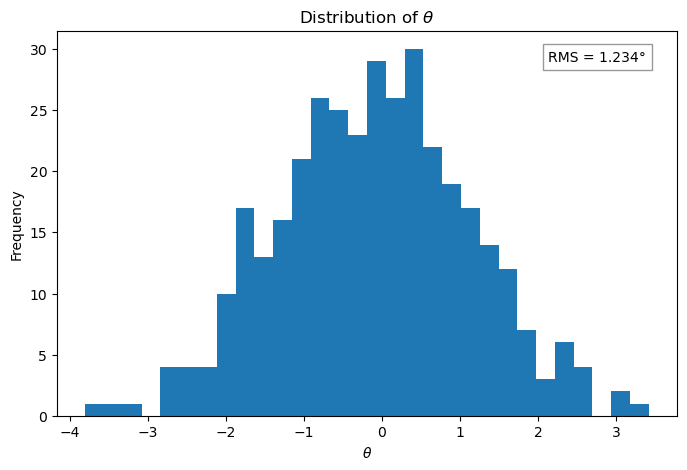

In [27]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_error_direction_signed_initial_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"${\theta}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of ${\theta}$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

In [38]:
apex_radial = calcular_apex_3d_gaia(result_hyades_sintetico_error_alld["cluster_result"]['data_initial'],sigma_clip=5.0)

In [ ]:
columns_bring = list(set(result_hyades_sintetico_error_alld["cluster_result"]["data_initial"].columns)-set(apex_radial.stars.columns))+["source_id"]
df2 = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_shell\dataset_100pc.csv")
apex_radial.stars.merge(result_hyades_sintetico_error_alld["cluster_result"]["data_initial"][columns_bring], how='inner', on="source_id").to_csv("analisis_radial_apex.csv")

In [70]:
single_mean_coord = SkyCoord(ra = apex_radial.stars["apex_ra_deg"].mean() * u.deg, dec = apex_radial.stars["apex_dec_deg"].mean() * u.deg)
single_median_coord = SkyCoord(ra = apex_radial.stars["apex_ra_deg"].median() * u.deg, dec = apex_radial.stars["apex_dec_deg"].median() * u.deg)
df_coords = SkyCoord(ra = apex_radial.stars["apex_ra_deg"].values * u.deg, dec = apex_radial.stars["apex_dec_deg"].values * u.deg)

In [73]:
apex_radial.stars["angular_mean_deviation"] = single_mean_coord.separation(df_coords).deg
apex_radial.stars["angular_median_deviation"] = single_median_coord.separation(df_coords).deg

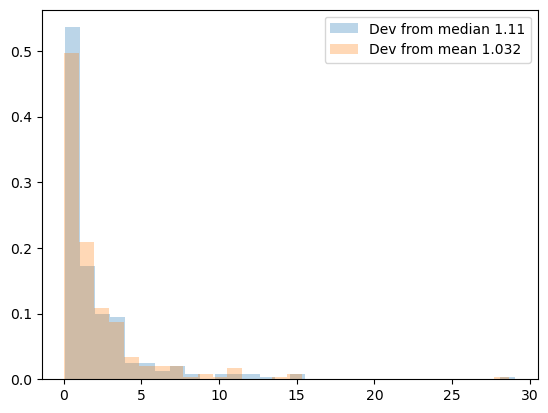

In [85]:
plt.hist(apex_radial.stars["angular_median_deviation"], label = f"Dev from median {np.round(apex_radial.stars["angular_mean_deviation"].median(),3)}", alpha = 0.3, density =True, bins = 30)
plt.hist(apex_radial.stars["angular_mean_deviation"], label = f"Dev from mean {np.round(apex_radial.stars["angular_median_deviation"].median(),3)}", alpha = 0.3, density = True, bins = 30)
plt.legend()
plt.show()

In [69]:
single_mean_coord

<SkyCoord (ICRS): (ra, dec) in deg
    (97.88665123, 6.74806164)>

In [87]:
print("=" * 60)
print("RESULTADOS DEL ÁPEX DEL CÚMULO")
print("=" * 60)

print(f"Número de estrellas           : {apex_radial.n_stars}")

print("\n--- Ápex (ICRS) ---")
print(f"RA                            : {apex_radial.apex_ra_deg:.6f} deg")
print(f"Dec                           : {apex_radial.apex_dec_deg:.6f} deg")

print("\n--- Antápex (ICRS) ---")
print(f"RA                            : {apex_radial.antapex_ra_deg:.6f} deg")
print(f"Dec                           : {apex_radial.antapex_dec_deg:.6f} deg")

print("\n--- Velocidad media ---")
print(f"|V|                           : {apex_radial.speed_mean_kms:.3f} km/s")

print("\n--- Dispersión angular ---")
print(f"RMS angular del ápex          : {apex_radial.sigma_apex_rms_deg:.4f} deg")

print("=" * 60)

RESULTADOS DEL ÁPEX DEL CÚMULO
Número de estrellas           : 251

--- Ápex (ICRS) ---
RA                            : 97.641022 deg
Dec                           : 6.891512 deg

--- Antápex (ICRS) ---
RA                            : 277.641022 deg
Dec                           : -6.891512 deg

--- Velocidad media ---
|V|                           : 46.315 km/s

--- Dispersión angular ---
RMS angular del ápex          : 3.7745 deg


In [88]:
print("=" * 60)
print("RESULTADOS DEL ÁPEX DEL CÚMULO")
print("=" * 60)

print(f"Número de estrellas inicial   : {result_hyades_sintetico_error_alld['cluster_result']['n_stars_initial']}")
print(f"Número de estrellas           : {result_hyades_sintetico_error_alld['cluster_result']['n_stars_refined']}")

print("\n--- Ápex (ICRS) ---")
print(f"RA                            : {result_hyades_sintetico_error_alld['cluster_result']['apex_refined']['apex_ra_deg']:.6f} deg")
print(f"Dec                           : {result_hyades_sintetico_error_alld['cluster_result']['apex_refined']['apex_dec_deg']:.6f} deg")

print("\n--- Antápex (ICRS) ---")
print(f"RA                            : {result_hyades_sintetico_error_alld['cluster_result']['apex_refined']['antapex_ra_deg']:.6f} deg")
print(f"Dec                           : {result_hyades_sintetico_error_alld['cluster_result']['apex_refined']['antapex_dec_deg']:.6f} deg")

print("\n--- Dispersión angular ---")
print(f"RMS angular del ápex          : {result_hyades_sintetico_error_alld['cluster_result']['apex_refined']['rms_pole_residual_deg']:.4f} deg")

print("=" * 60)

RESULTADOS DEL ÁPEX DEL CÚMULO
Número de estrellas inicial   : 400
Número de estrellas           : 358

--- Ápex (ICRS) ---
RA                            : 96.821150 deg
Dec                           : 7.169836 deg

--- Antápex (ICRS) ---
RA                            : 276.821150 deg
Dec                           : -7.169836 deg

--- Dispersión angular ---
RMS angular del ápex          : 0.5054 deg


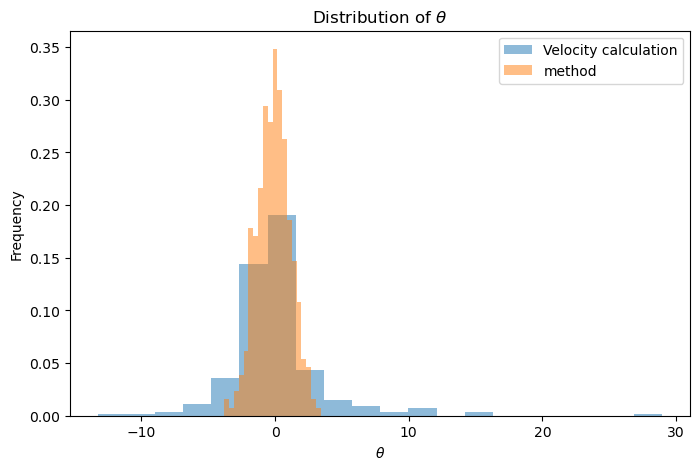

In [96]:
# Graficar
plt.figure(figsize=(8, 5))
plt.hist(apex_radial.stars["apex_angular_residual_signed_deg"], density=True, bins=20, alpha=0.5, label="Velocity calculation")
plt.hist(result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_error_direction_signed_initial_deg"], density=True, bins=20, alpha=0.5, label="method")
plt.xlabel(r"${\theta}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of ${\theta}$")
plt.legend()

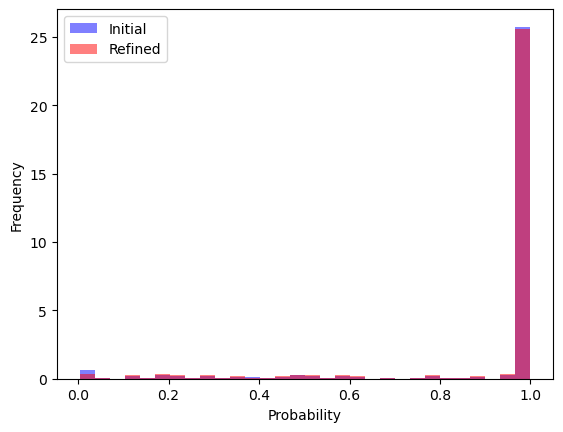

In [27]:
plt.hist(result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["probabilidad"],color="blue", alpha=0.5, bins=30, density=True, label="Initial")
plt.hist(result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["probabilidad"],color="red", alpha=0.5, bins=30, density=True, label="Refined")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Text(0, 0.5, 'Probability')

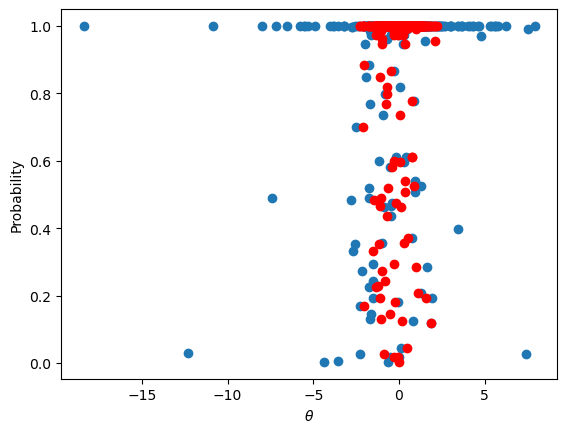

In [28]:
x = result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["pole_apex_error_direction_signed_initial_deg"]
y = result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["probabilidad"]
x1 = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_error_direction_signed_refined_deg"]
y1 = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["probabilidad"]
plt.scatter(x, y)
plt.scatter(x1, y1,color="red")
plt.xlabel(r"${\theta}$")
plt.ylabel("Probability")  

(array([ 49.,   3.,   2.,   0.,   0.,   2.,   2.,   5.,   3., 334.]),
 array([1.00723121e-25, 1.00000000e-01, 2.00000000e-01, 3.00000000e-01,
        4.00000000e-01, 5.00000000e-01, 6.00000000e-01, 7.00000000e-01,
        8.00000000e-01, 9.00000000e-01, 1.00000000e+00]),
 <BarContainer object of 10 artists>)

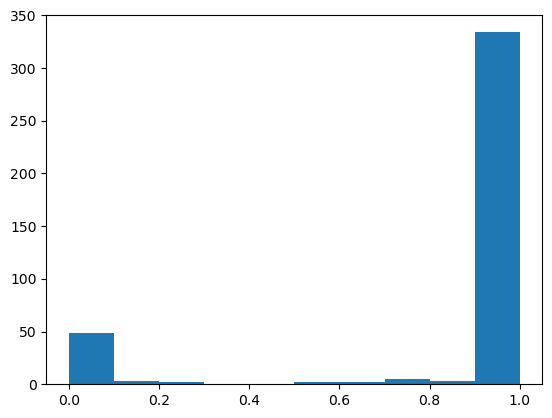

In [40]:
plt.hist(result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["peso"])

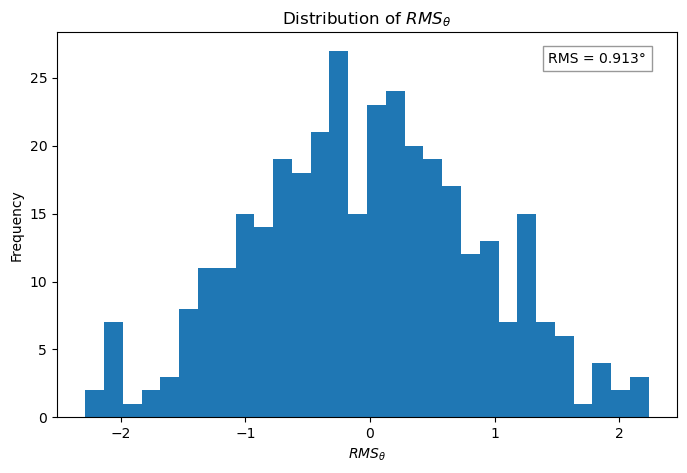

In [29]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_error_direction_signed_refined_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$RMS_{\theta}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $RMS_{\theta}$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

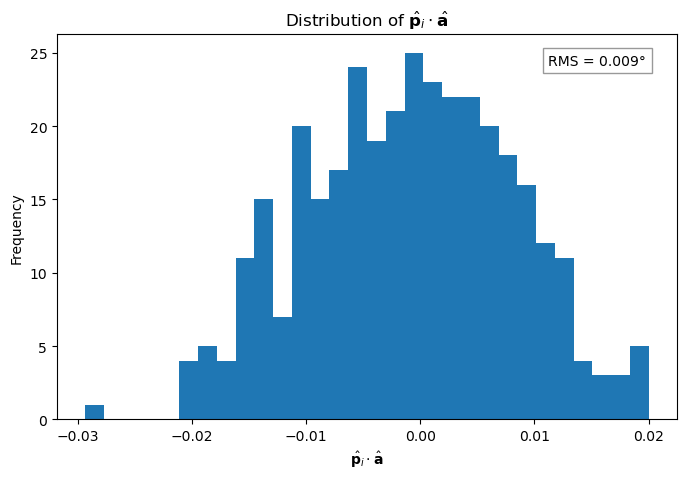

In [31]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_dot_initial"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$\hat{\mathbf{p}}_i\cdot\hat{\mathbf{a}}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\hat{\mathbf{p}}_i\cdot\hat{\mathbf{a}}$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()


CLUSTER VALIDATION SUMMARY — ICRS / Gaia


,value
cluster_id,0_8
n_stars,400
n_stars_refined,347
fraction_kept,0.8675
apex_ra_deg,96.933984
apex_dec_deg,7.133738
antapex_ra_deg,276.933984
antapex_dec_deg,-7.133738
rms_pole_residual_deg,0.448635
median_pole_residual_deg,-0.012651



INTERPRETATION FLAGS
RMS pole residual          : 0.4486 deg
Median pole residual       : -0.0127 deg
Toward-apex fraction       : 1.0000
Fraction kept after filter : 0.8675
Apex-cross separation      : 0.1502 deg
Pole residuals             : GOOD, strong common-motion geometry.
Motion orientation         : GOOD, most stars move toward the recovered apex.
Apex estimator agreement   : GOOD, eigen and pole-cross estimators agree.


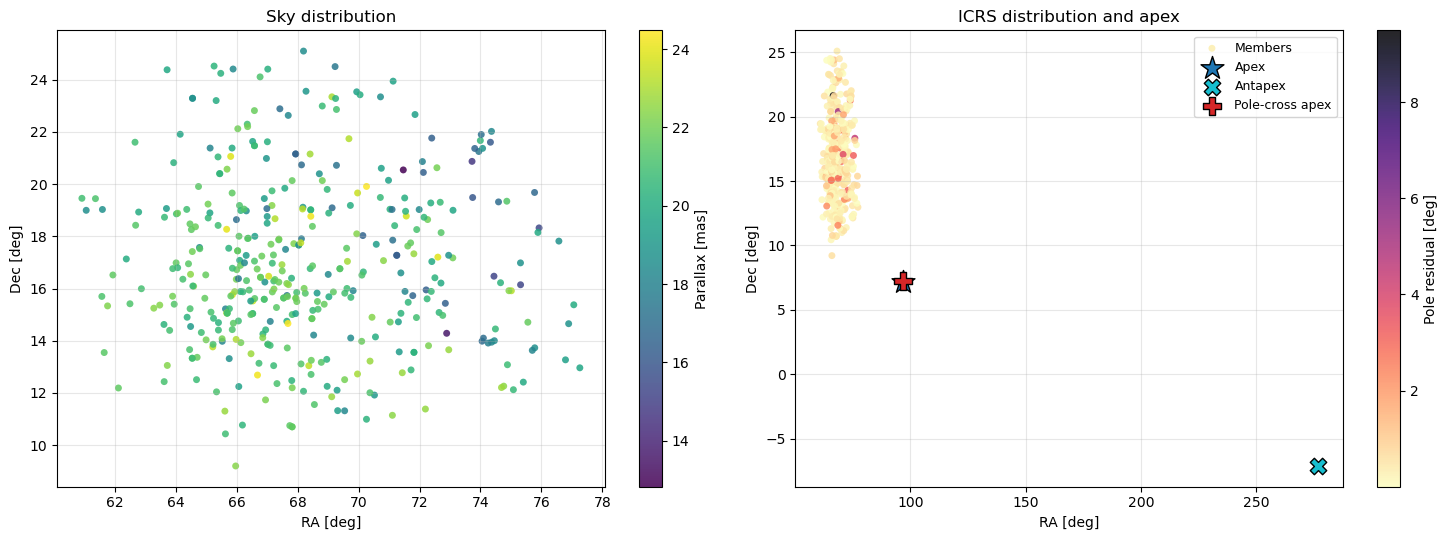

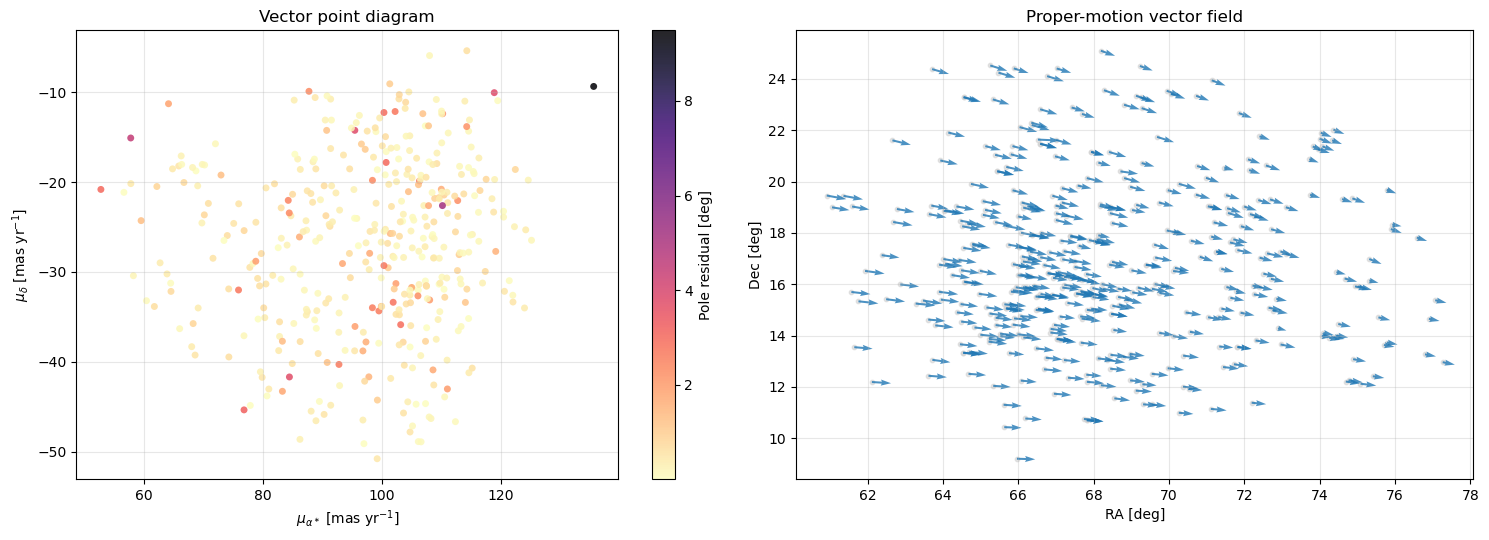

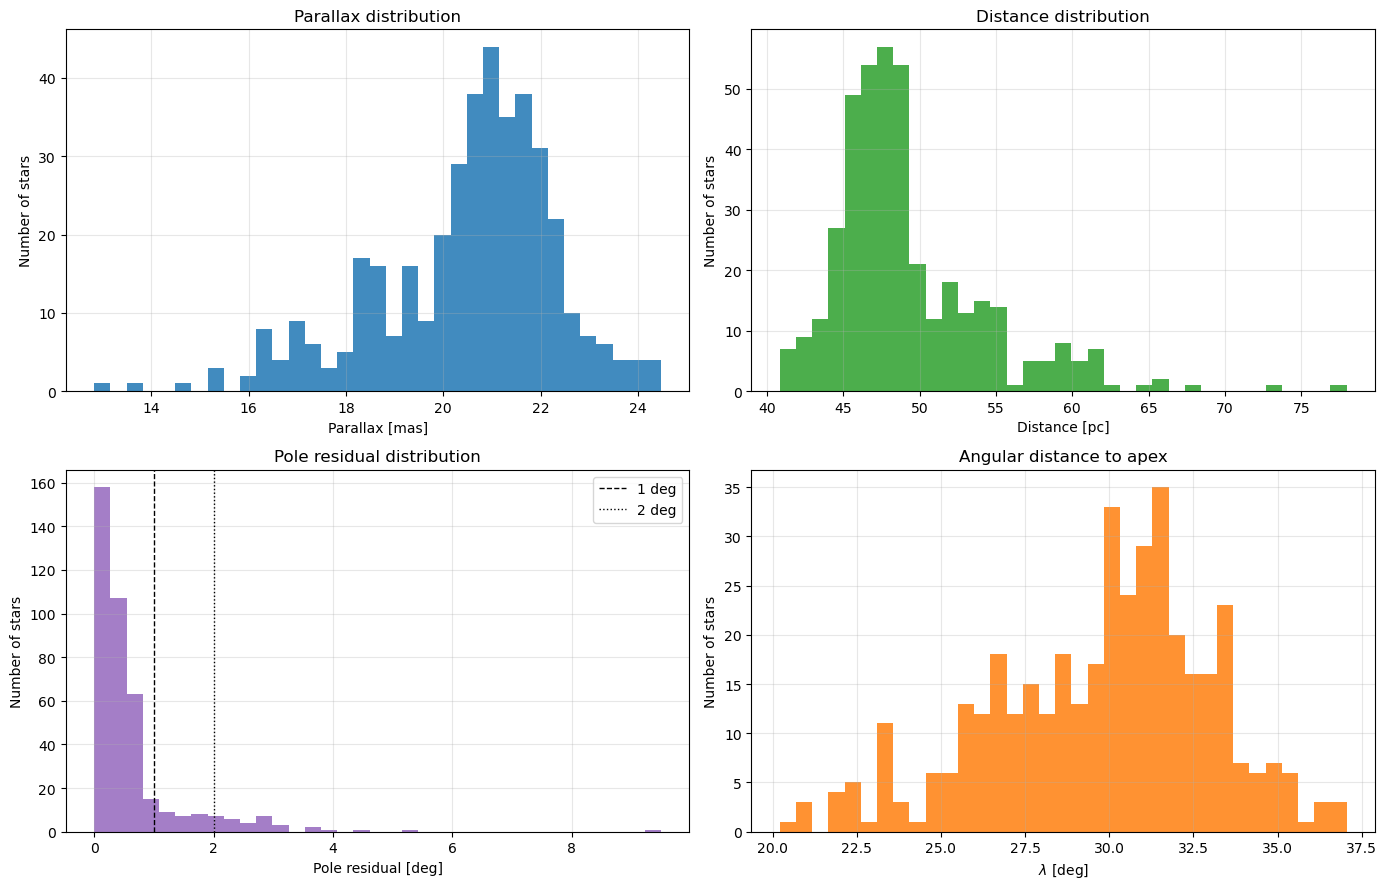

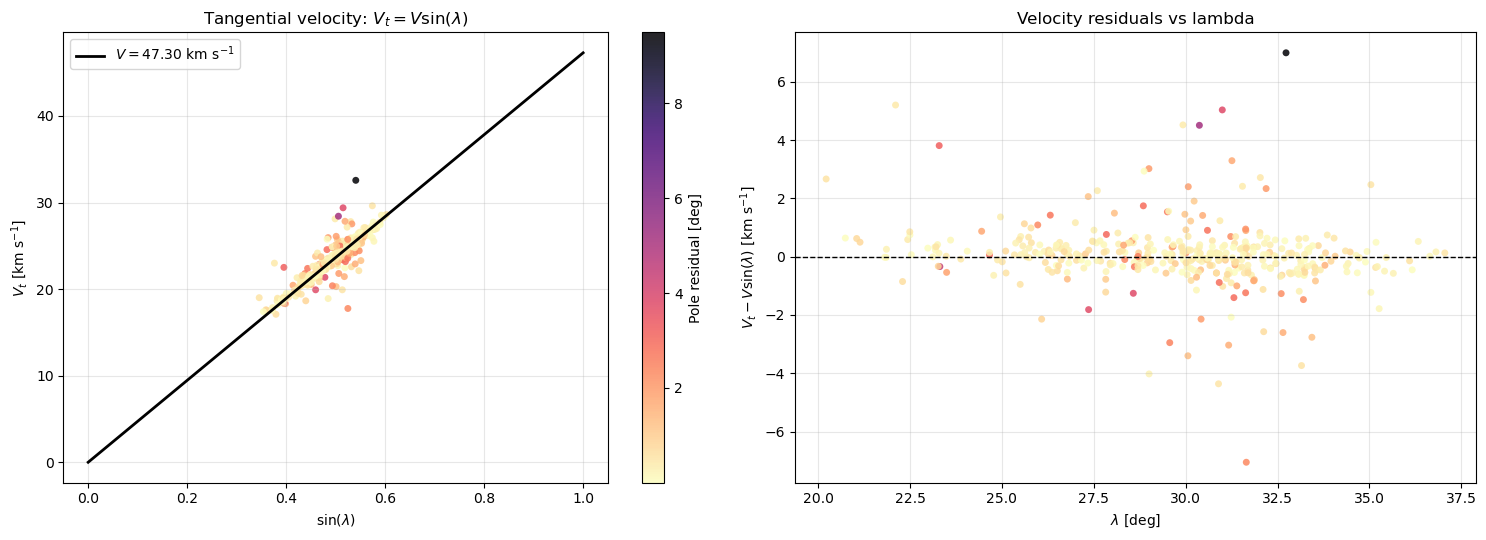

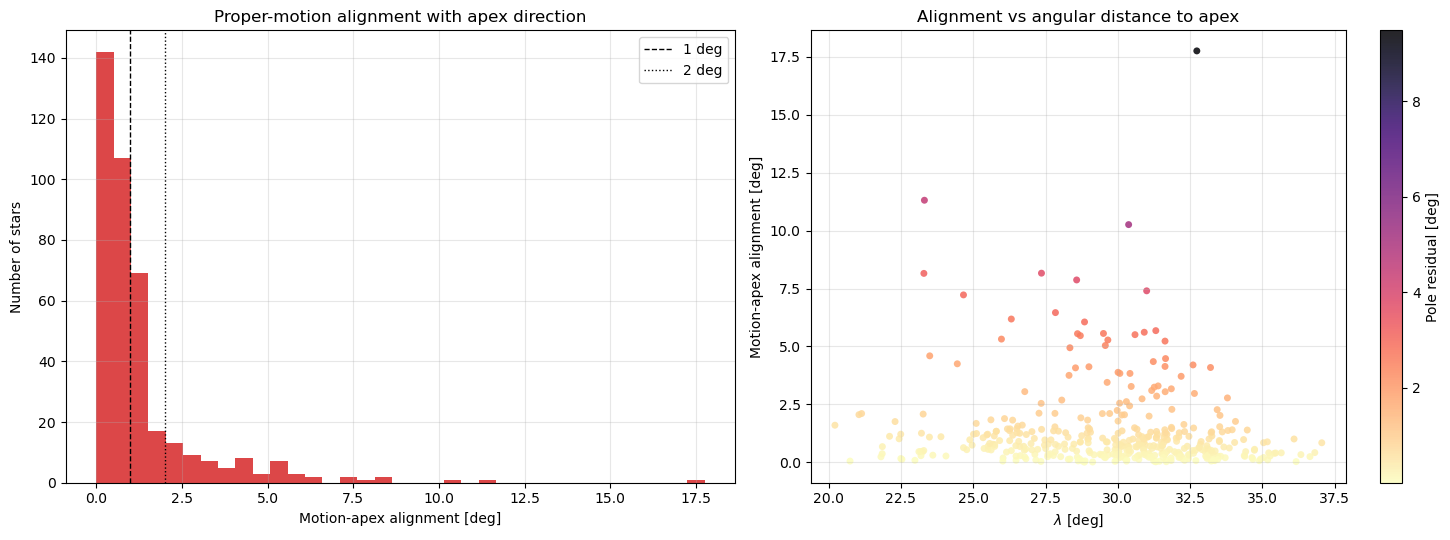

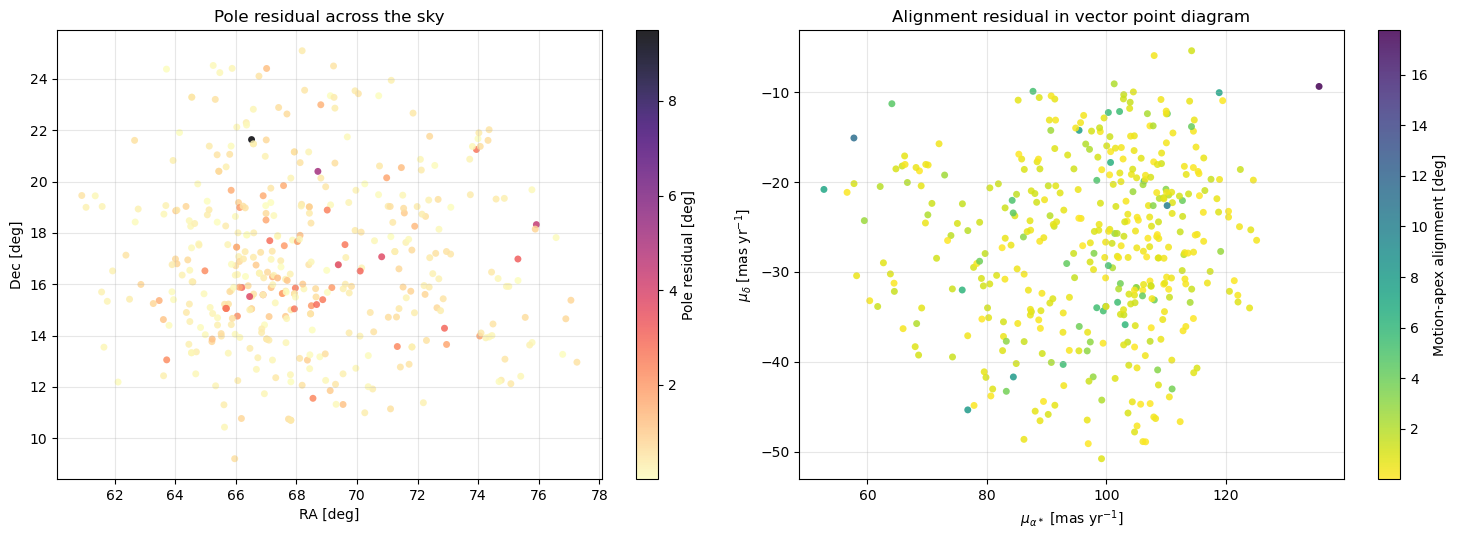

C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\src\utils.py:2452: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


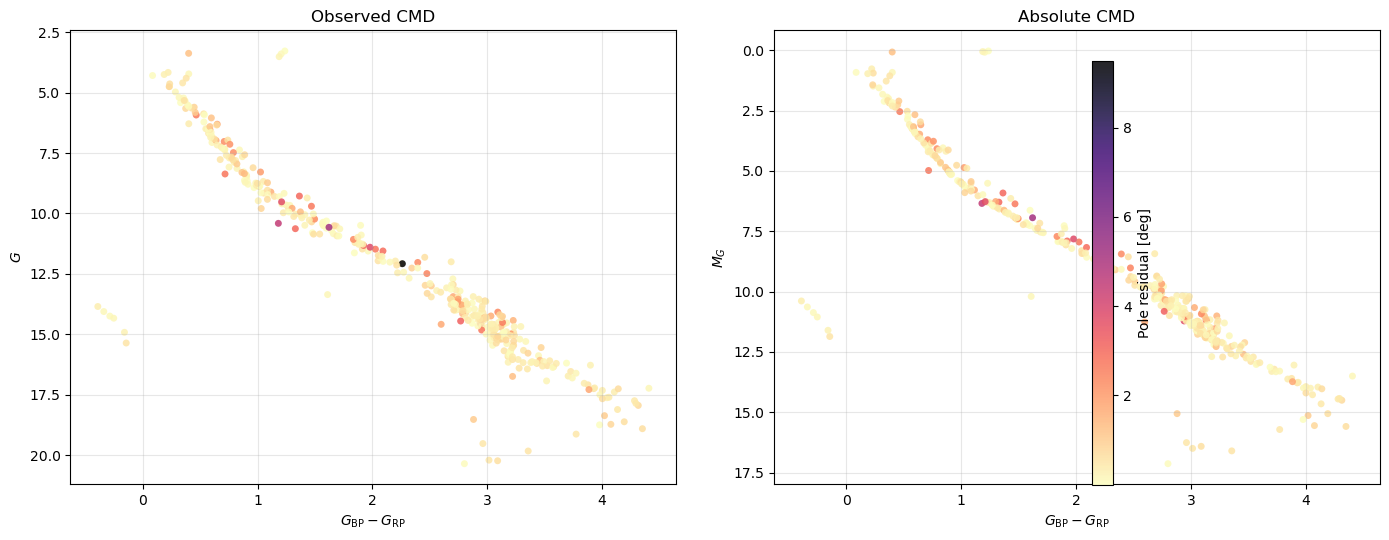


Returned objects
summary_df : global validation metrics
df_diag    : star-by-star diagnostic table
boot_df    : bootstrap apex table


In [32]:
summary_df, df_diag, boot_df = show_cluster_validation_products_icrs(
    result_hyades_sintetico_error_alld["cluster_result"],
    bootstrap_n=500,
)

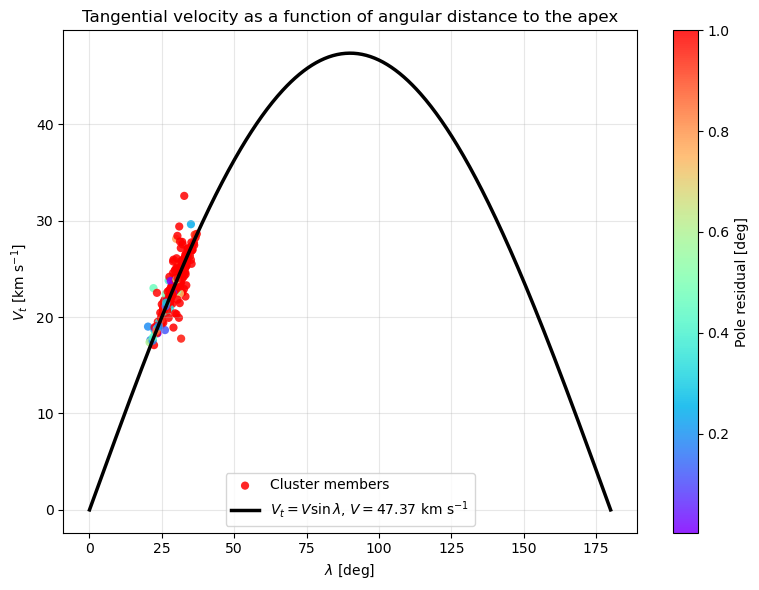

Fitted cluster speed from V_t = V sin(lambda): 47.372 km/s


In [33]:
# Datos
lambda_deg = df_diag["lambda_deg"].to_numpy(dtype=float)
vt_kms = df_diag["vt_kms"].to_numpy(dtype=float)
# residual = df_diag["pole_residual_deg"].to_numpy(dtype=float)
residual = df_diag["probabilidad"].to_numpy(dtype=float)

# Ajuste V_t = V sin(lambda)
lambda_rad = np.radians(lambda_deg)
sin_lambda = np.sin(lambda_rad)

valid = (
    np.isfinite(lambda_deg)
    & np.isfinite(vt_kms)
    & np.isfinite(sin_lambda)
    & (sin_lambda > 0)
)

x = sin_lambda[valid]
y = vt_kms[valid]

V_fit = np.sum(x * y) / np.sum(x * x)

# Curva teórica ajustada
lambda_grid_deg = np.linspace(0, 180, 500)
lambda_grid_rad = np.radians(lambda_grid_deg)
vt_model = V_fit * np.sin(lambda_grid_rad)

# Gráfica
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    lambda_deg,
    vt_kms,
    c=residual,
    s=35,
    cmap="rainbow",
    alpha=0.85,
    edgecolor="none",
    label="Cluster members",
)

plt.plot(
    lambda_grid_deg,
    vt_model,
    color="black",
    lw=2.5,
    label=rf"$V_t = V \sin\lambda$, $V = {V_fit:.2f}$ km s$^{{-1}}$",
)

plt.colorbar(sc, label="Pole residual [deg]")

plt.xlabel(r"$\lambda$ [deg]")
plt.ylabel(r"$V_t$ [km s$^{-1}$]")
plt.title(r"Tangential velocity as a function of angular distance to the apex")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fitted cluster speed from V_t = V sin(lambda): {V_fit:.3f} km/s")

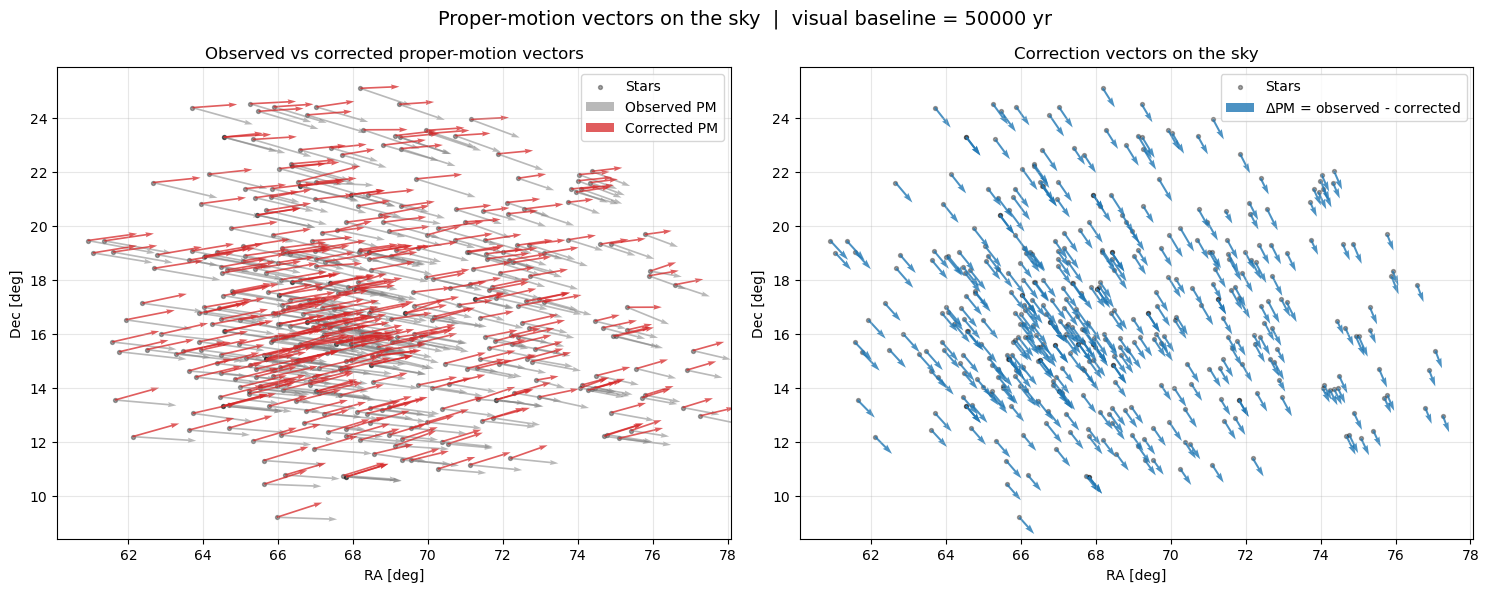

In [34]:
plot_pm_vectors_on_sky(
    result_hyades_classic_solar["data"],
    ra_col="ra",
    dec_col="dec",
    pmra_col="pmra",
    pmdec_col="pmdec",
    pmra_corr_col="pmra_corr",
    pmdec_corr_col="pmdec_corr",
    years=50000,
    max_stars=1000,
    random_state=42,
    figsize=(15, 6),
    title="Proper-motion vectors on the sky",
    save_path=None,
)

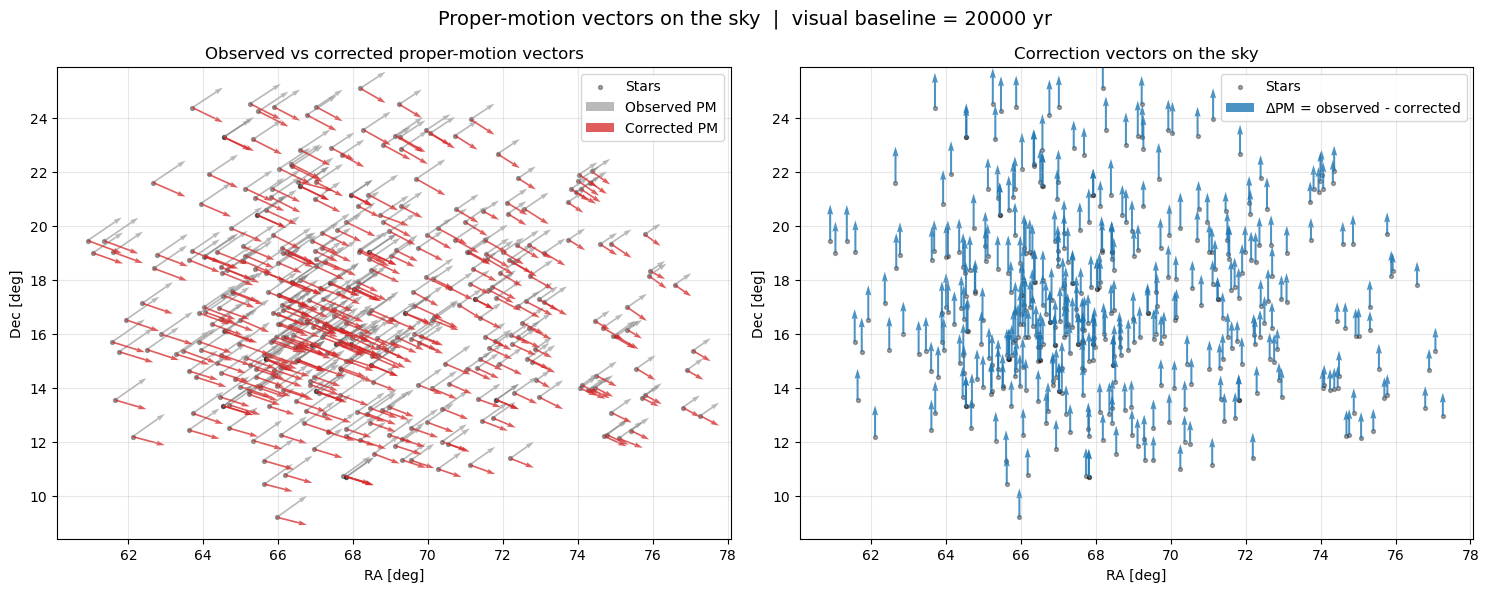

In [35]:
result_hyades_classic_solar["data"]["pmra_solar"] =  result_hyades_classic_solar["data"]["pmra"] - result_hyades_classic_solar["data"]["d_pmra_corr"]
result_hyades_classic_solar["data"]["pmdec_solar"] =  result_hyades_classic_solar["data"]["pmdec"] - result_hyades_classic_solar["data"]["d_pmdec_corr"]
plot_pm_vectors_on_sky(
    result_hyades_classic_solar["data"],
    ra_col="ra",
    dec_col="dec",
    pmra_col="pmra_solar",
    pmdec_col="pmra_solar",
    pmra_corr_col="pmra_solar",
    pmdec_corr_col="pmdec_solar",
    years=20000,
    max_stars=1000,
    random_state=42,
    figsize=(15, 6),
    title="Proper-motion vectors on the sky",
    save_path=None,
)

In [36]:
# 3. Esfera interactiva
fig3 = plot_cluster_motion_geometry(
    result_hyades_sintetico_error_alld["data"],
    analysis_result=result_hyades_sintetico_error_alld,
    projection="sphere",
    title="Cúmulo 8 en esfera interactiva",
    save_html="cluster_hyades_sphere.html",
)

fig3.show()